# 01e — Redaction Impact Assessment
Quantify redaction extent in ASRS narratives using `src.features.text`.

In [6]:
import os
from pathlib import Path

# Find project root (contains pyproject.toml)
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
print(f"Working directory: {root}")

Working directory: e:\OSFDA


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import load_main_config
from src.data.loader import load_raw_data
from src.features.text import preprocess_narratives, redaction_stats

config = load_main_config()
df = load_raw_data(config)
print(f'Loaded {len(df)} records.')

Loaded 38655 records from E:\OSFDA\data\raw\asrs_full.parquet
Loaded 38655 records.


## 1. Redaction Statistics

In [8]:
stats_df = redaction_stats(df)
df = pd.concat([df, stats_df], axis=1)

reports_with_redactions = (df['redaction_count'] > 0).sum()
total_redactions = df['redaction_count'].sum()
avg_redactions = df['redaction_count'].mean()

print(f"Reports with redactions: {reports_with_redactions} ({reports_with_redactions/len(df)*100:.1f}%)")
print(f"Total redaction tokens: {total_redactions}")
print(f"Average redactions per report: {avg_redactions:.2f}")

Reports with redactions: 9054 (23.4%)
Total redaction tokens: 22740
Average redactions per report: 0.59


## 2. Visualize Redaction Impact

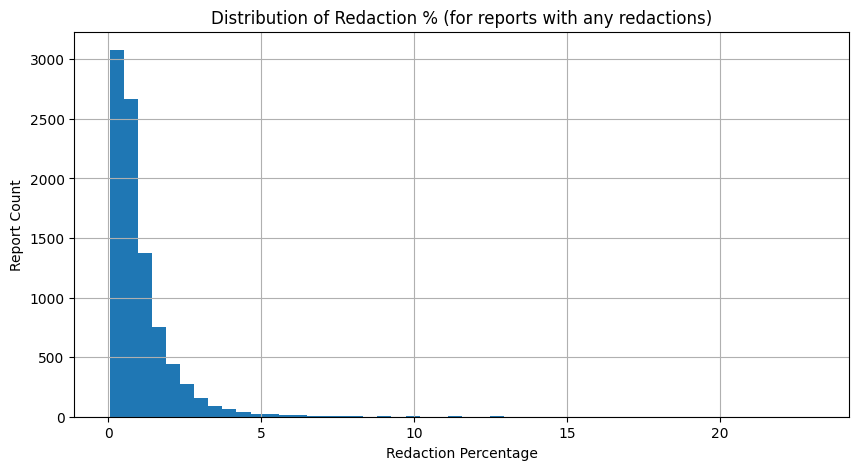

In [9]:
plt.figure(figsize=(10, 5))
df[df['redaction_count'] > 0]['redaction_pct'].hist(bins=50)
plt.title('Distribution of Redaction % (for reports with any redactions)')
plt.xlabel('Redaction Percentage')
plt.ylabel('Report Count')
plt.show()

## 3. Preprocess Narratives

In [10]:
df = preprocess_narratives(df)

# Show sample comparison
sample = df[df['Report 1_Narrative'].str.contains('ZZZ', na=False)].sample(1, random_state=42)
print('--- RAW NARRATIVE ---')
print(str(sample['Report 1_Narrative'].values[0])[:500] + "...")
print('\n--- CLEANED NARRATIVE ---')
print(str(sample['Report 1_Narrative_clean'].values[0])[:500] + "...")

--- RAW NARRATIVE ---
While serving as First Officer; the following event occurred.After takeoff while performing the After Takeoff Flow Checklist; crew noticed illuminated BAGG EXT button at approximately 4;000 ft. Crew [advised ATC]; and asked to return to ZZZ while also requesting assistance from Crash Fire Rescue. Crew performed the [recommended procedure] in the QRH; returned and landed safely at ZZZ on Runway XXR. Crash Fire Rescue crews inspected the baggage compartment on the taxiway and then escorted the air...

--- CLEANED NARRATIVE ---
While serving as First Officer; the following event occurred.After takeoff while performing the After Takeoff Flow Checklist; crew noticed illuminated BAGG EXT button at approximately 4;000 ft. Crew [advised ATC]; and asked to return to [REDACTED] while also requesting assistance from Crash Fire Rescue. Crew performed the [recommended procedure] in the QRH; returned and landed safely at [REDACTED] on Runway XXR. Crash Fire Rescue crews inspect